In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import os

import numpy as np
from sklearn.preprocessing import normalize

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using: {device}")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using: mps


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [3]:
df = pd.read_csv("../data/npc.csv")
df["has_chathead"] = df["id"].apply(lambda i: os.path.exists(f"../data/chatheads/{i}.png"))

df = df.rename(columns={"Race": "Class"})
df["Class"] = df["Class"].replace({
    "Citizen of Arceuus": "Human",
    "Dwarf ( Imcando-descendant )": "Dwarf"
})

sample = df[(df["has_chathead"]) & (df["Class"] == "Human")].sample(10, random_state=42)

In [ ]:
def has_beard(npc_id):
    img = Image.open(f"../data/chatheads/{npc_id}.png").convert("RGB")
    inputs = clip_processor(
        text=["a character with a beard", "a character without a beard"],
        images=img,
        return_tensors="pt",
        padding=True
    ).to(device)
    with torch.no_grad():
        logits = clip_model(**inputs).logits_per_image
        probs = logits.softmax(dim=1).squeeze().cpu().tolist()
    return probs[0] > probs[1], round(probs[0], 3)

def get_attributes(npc_id):
    img = Image.open(f"../data/chatheads/{npc_id}.png").convert("RGB")
    
    def binary(text_pos, text_neg, threshold=0.5):
        inputs = clip_processor(
            text=[text_pos, text_neg],
            images=img, return_tensors="pt", padding=True
        ).to(device)
        with torch.no_grad():
            probs = clip_model(**inputs).logits_per_image.softmax(dim=1).squeeze().cpu().tolist()
        return probs[0] > threshold, round(probs[0], 3)

    def categorical(options):
        inputs = clip_processor(
            text=options,
            images=img, return_tensors="pt", padding=True
        ).to(device)
        with torch.no_grad():
            probs = clip_model(**inputs).logits_per_image.softmax(dim=1).squeeze().cpu().tolist()
        return options[probs.index(max(probs))], round(max(probs), 3)

    has_beard, beard_conf = binary("a character with a beard", "a character without a beard")
    has_mustache, must_conf = binary("a character with a mustache", "a character without a mustache")
    has_eyewear, eye_conf = binary("a character wearing glasses or goggles", "a character with no eyewear", threshold=0.65)    headwear, head_conf = categorical([
        "a character wearing a hat",
        "a character wearing a hood",
        "a character wearing a mask",
        "a character wearing a helmet",
        "a character with no headwear"
    ])

    return {
        "has_beard": has_beard, "beard_conf": beard_conf,
        "has_mustache": has_mustache, "mustache_conf": must_conf,
        "has_eyewear": has_eyewear, "eyewear_conf": eye_conf,
        "headwear": headwear, "headwear_conf": head_conf,
    }

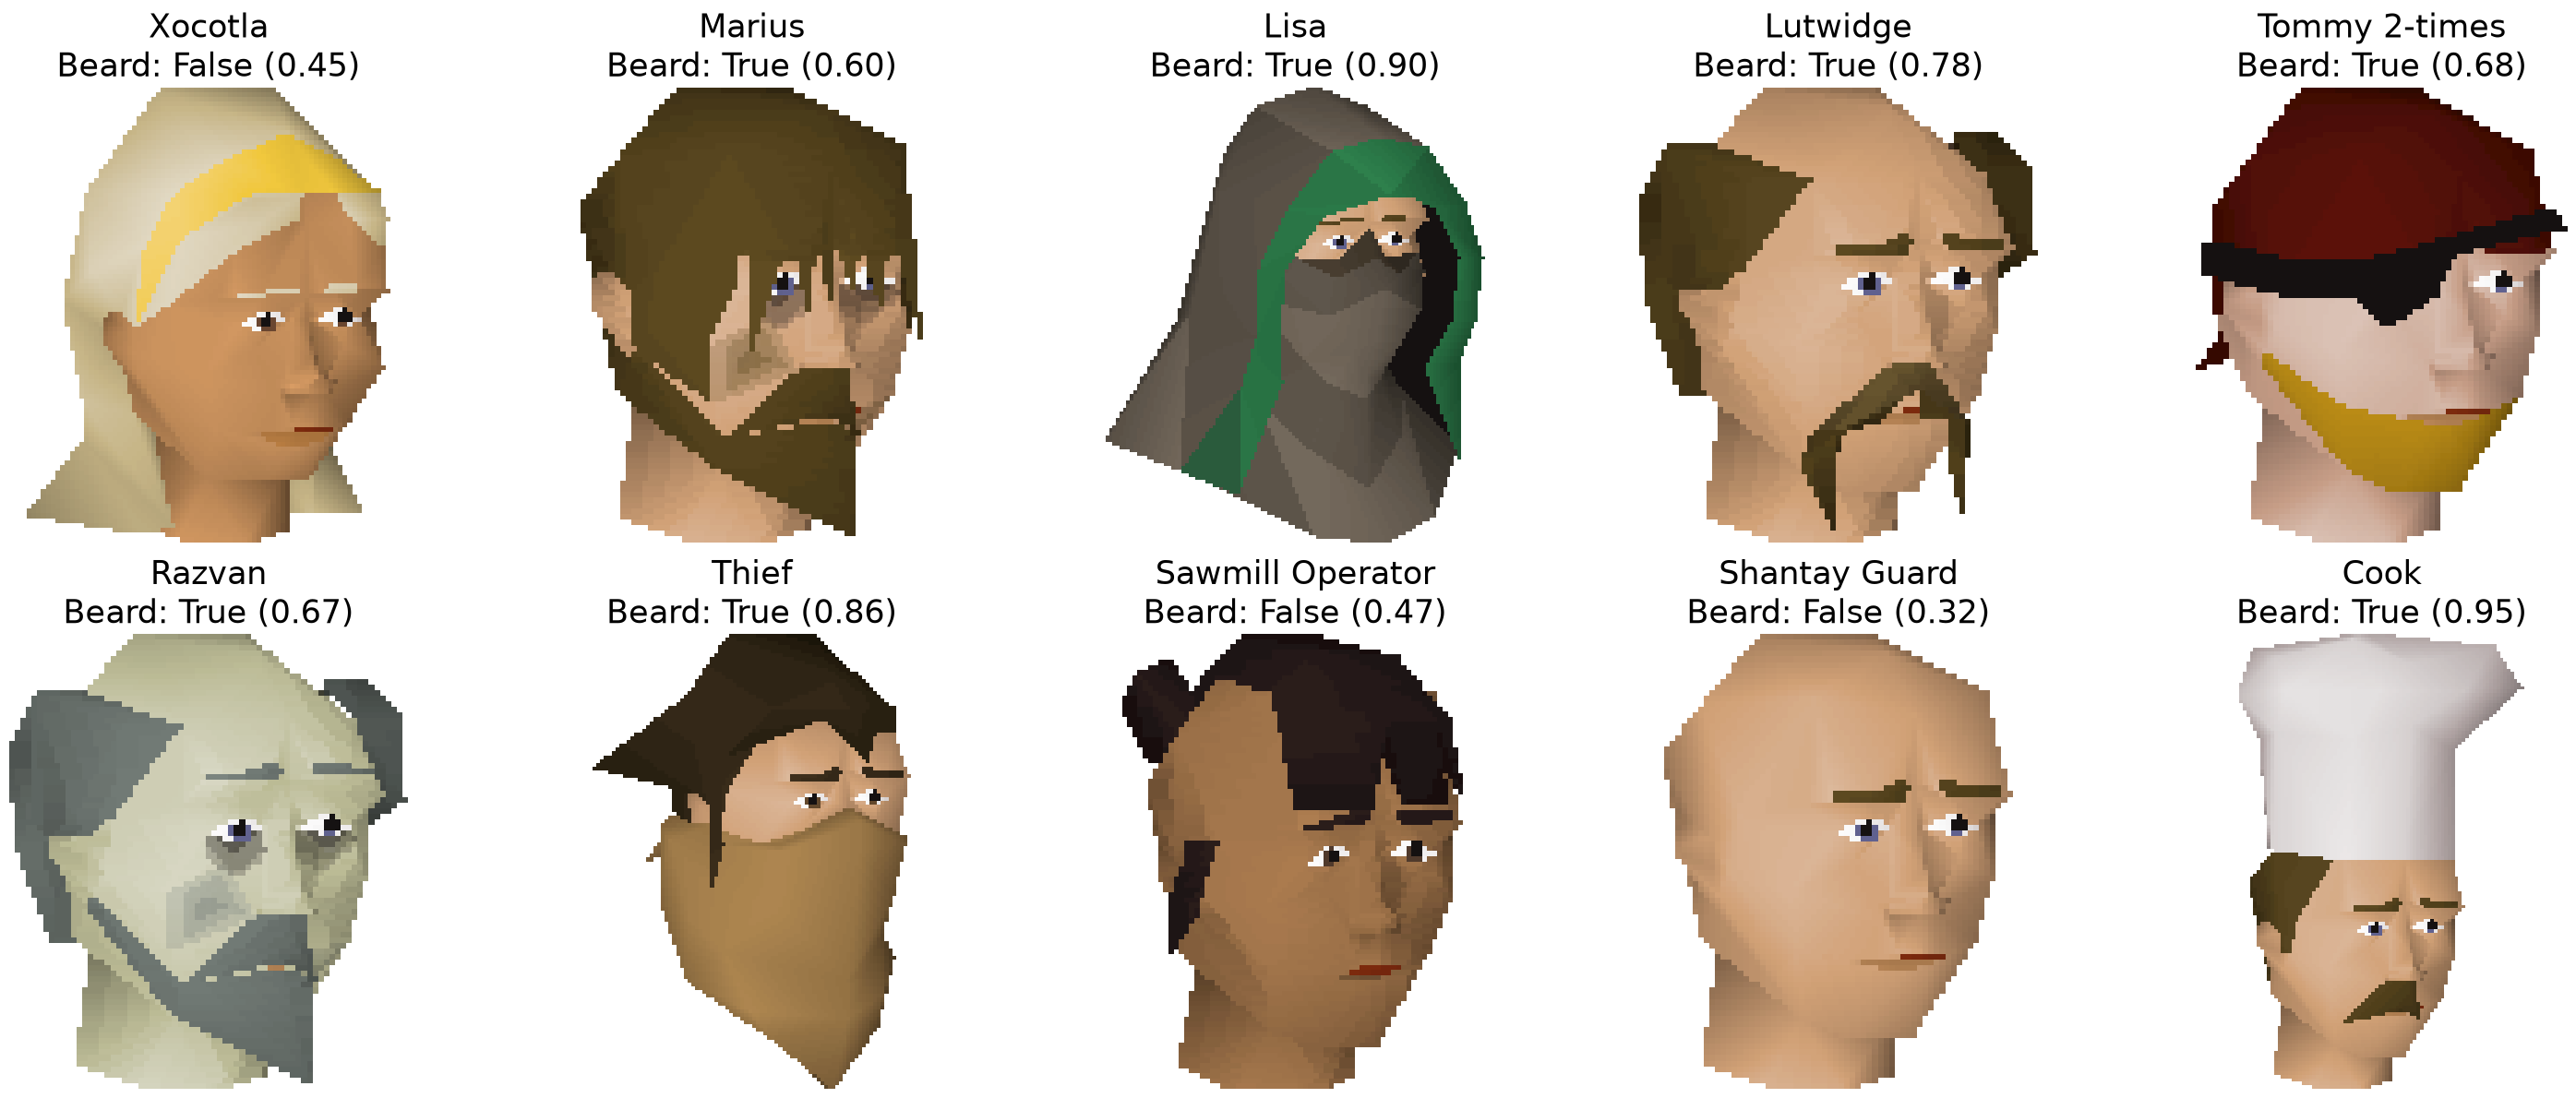

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(30, 12))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    beard, conf = has_beard(row["id"])
    img = Image.open(f"../data/chatheads/{row['id']}.png")
    ax.imshow(img)
    ax.set_title(f"{row['Name']}\nBeard: {beard} ({conf:.2f})", fontsize=25)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# test on one NPC first
test_id = df[df["has_chathead"]].iloc[100]["id"]
print(get_attributes(test_id))

{'has_beard': False, 'beard_conf': 0.427, 'has_mustache': False, 'mustache_conf': 0.279, 'has_eyewear': True, 'eyewear_conf': 0.595, 'headwear': 'a character with no headwear', 'headwear_conf': 0.4}


In [14]:
print(df[df["has_chathead"]].iloc[100][["id", "Name"]])

id         121
Name    Amelia
Name: 121, dtype: object


In [19]:
def show_attributes(random_seed=42):
    sample = df[df["has_chathead"] & (df["Class"] == "Human")].sample(10, random_state=random_seed)

    fig, axes = plt.subplots(10, 2, figsize=(12, 40))

    for i, (_, row) in enumerate(sample.iterrows()):
        attrs = get_attributes(row["id"])
        img = Image.open(f"../data/chatheads/{row['id']}.png")

        # left: chathead
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(row["Name"], fontsize=14)
        axes[i, 0].axis("off")

        # right: attribute grid
        labels = ["Beard", "Mustache", "Eyewear", "Headwear"]
        values = [
            f"{'Pred Yes' if attrs['has_beard'] else 'Pred No'} ({attrs['beard_conf']})",
            f"{'Pred Yes' if attrs['has_mustache'] else 'Pred No'} ({attrs['mustache_conf']})",
            f"{'Pred Yes' if attrs['has_eyewear'] else 'Pred No'} ({attrs['eyewear_conf']})",
            f"{attrs['headwear'].replace('a character ', '').replace('wearing ', '').replace('with no headwear', 'none')} ({attrs['headwear_conf']})"
        ]
        axes[i, 1].axis("off")
        for j, (label, value) in enumerate(zip(labels, values)):
            axes[i, 1].text(0.05, 0.8 - j * 0.22, f"{label}: {value}", fontsize=13, transform=axes[i, 1].transAxes)

    plt.tight_layout()
    plt.show()

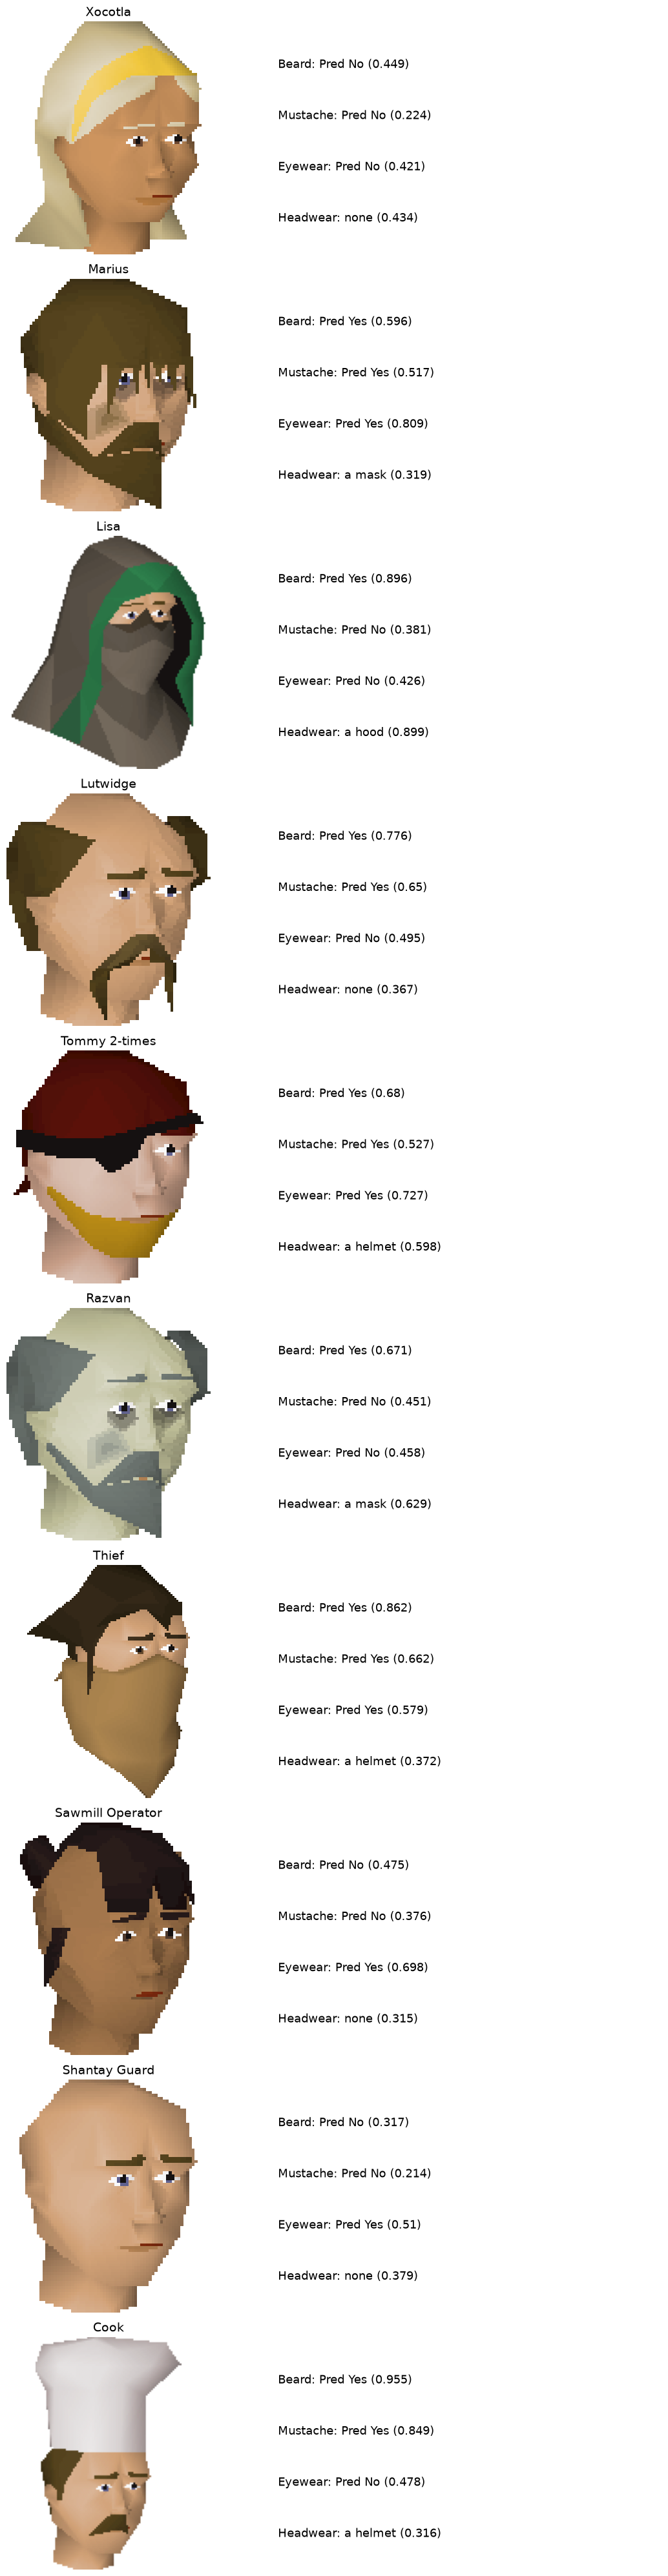

In [20]:
show_attributes(random_seed=42)

# RAG plan
- Run all chatheads through CLIP image encoder → 512-dim vector per NPC
- Run all bodies through CLIP image encoder → 512-dim vector per NPC
- Average the two vectors → one combined vector per NPC (connected via ID, so always same NPC's chathead + body)
- At query time, encode the text query → find top-k closest combined vectors via cosine similarity
- Return top matches showing both chathead and body side by side with NPC name

Averaging the two embeddings is the simplest fusion — it treats chathead and body as equally important. We could also concatenate (1024-dim) and weight them differently, but average is a good start.

Looping over all 3,477 NPCs that have both images. For each one, running the chathead and body through CLIP's image encoder to get two 512-dim vectors, averaging them into one, and stacking them into a matrix. That matrix is the search index — one row per NPC. `embedding_ids` just maps each row back to an NPC id so we can look up names later.

In [53]:
df["has_body"] = df["id"].apply(lambda i: os.path.exists(f"../data/bodies/{i}.png"))
npc_ids_list = df[df["has_chathead"] & df["has_body"]]["id"].tolist()
chathead_embeddings = []
body_embeddings = []

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
clip_model = clip_model.to(device)

for i, npc_id in enumerate(npc_ids_list):
    if i % 100 == 0:
        print(f"{i}/{len(npc_ids_list)}")

    ch_img = Image.open(f"../data/chatheads/{npc_id}.png").convert("RGB")
    inputs = clip_processor(text=["image"], images=ch_img, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        ch_emb = clip_model(**inputs).image_embeds.cpu().numpy()
    chathead_embeddings.append(ch_emb)

    b_img = Image.open(f"../data/bodies/{npc_id}.png").convert("RGB")
    inputs = clip_processor(text=["image"], images=b_img, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        b_emb = clip_model(**inputs).image_embeds.cpu().numpy()
    body_embeddings.append(b_emb)

chathead_embeddings = np.vstack(chathead_embeddings)
body_embeddings = np.vstack(body_embeddings)
combined = normalize((chathead_embeddings + body_embeddings) / 2)
npc_ids = np.array(npc_ids_list)
print(f"Done: {len(npc_ids)} NPCs, shape: {combined.shape}")
np.save("../data/combined_embeddings.npy", combined)
np.save("../data/embedding_ids.npy", npc_ids)

0/3468


/Users/oliver/Documents/UChicago/computer-vision/cv/cv_env/lib/python3.11/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/3468
200/3468
300/3468
400/3468
500/3468
600/3468
700/3468
800/3468
900/3468
1000/3468
1100/3468
1200/3468
1300/3468
1400/3468
1500/3468
1600/3468
1700/3468
1800/3468
1900/3468
2000/3468
2100/3468
2200/3468
2300/3468
2400/3468
2500/3468
2600/3468
2700/3468
2800/3468
2900/3468
3000/3468
3100/3468
3200/3468
3300/3468
3400/3468
Done: 3468 NPCs, shape: (3468, 512)


In [54]:
print(combined.shape) # should be (3468, 512)

(3468, 512)


combined_embeddings.npy — a matrix of shape (3477, 512). Each row is one NPC's combined visual embedding — a 512-dimensional vector that represents what that NPC looks like, averaged from their chathead and body images. Numbers mean nothing on their own but the geometry does — similar-looking NPCs will have similar vectors.

embedding_ids.npy — a 1D array of length 3477 containing the NPC id values in the same order as the rows in combined_embeddings.npy. So row 0 of the embeddings corresponds to id = embedding_ids[0], which you can look up in npc.csv to get the name, class, etc.

At search time: you encode a text query into a 512-dim vector using the same CLIP model, then find which rows in combined_embeddings.npy are closest to it via cosine similarity — those are the most visually matching NPCs.

In [ ]:
combined = np.load("../data/combined_embeddings.npy")
npc_ids = np.load("../data/embedding_ids.npy")

In [ ]:
def search(query, top_k=5):
    inputs = clip_processor(text=[query], images=Image.new("RGB", (224, 224)), return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_emb = clip_model(**inputs).text_embeds.cpu().numpy()
    text_emb = normalize(text_emb)

    scores = (combined @ text_emb.T).squeeze()
    top_idx = np.argsort(-scores)[:top_k]

    return [
        {"id": int(npc_ids[i]), "name": df.loc[df["id"] == npc_ids[i], "Name"].values[0], "score": float(scores[i])}
        for i in top_idx
    ]

def plot_results(results, query):
    top_k = len(results)
    fig, axes = plt.subplots(top_k, 2, figsize=(6, top_k * 2))
    for i, r in enumerate(results):
        axes[i, 0].imshow(Image.open(f"../data/chatheads/{r['id']}.png"))
        axes[i, 0].set_title(f"{r['name']} ({r['score']:.3f})", fontsize=11)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(Image.open(f"../data/bodies/{r['id']}.png"))
        axes[i, 1].axis("off")
    plt.suptitle(f'Query: "{query}"', fontsize=13)
    plt.tight_layout()
    plt.show()

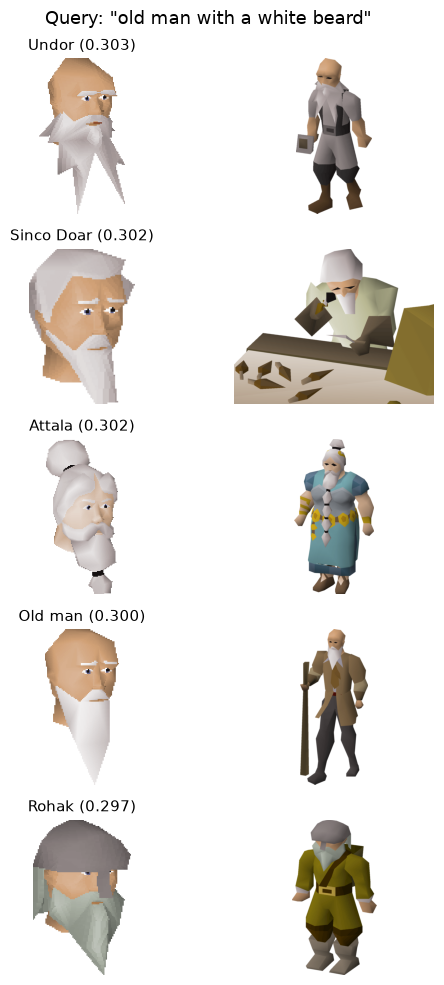

In [ ]:
# usage
query = "old man with a white beard"
results = search(query)
plot_results(results, query)

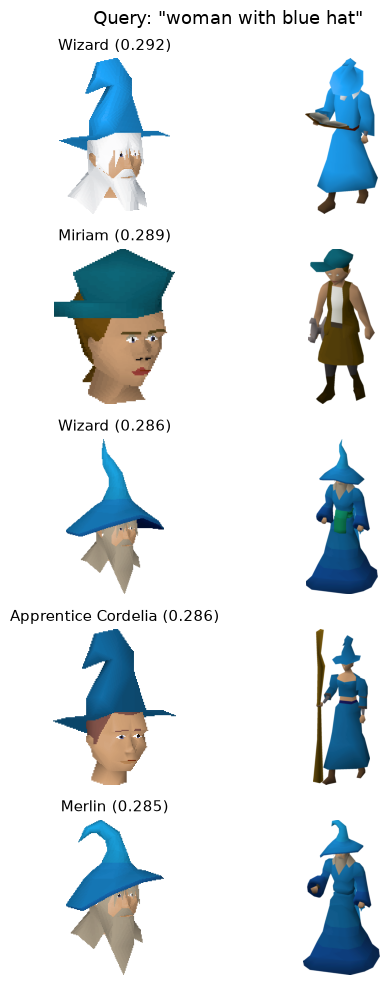

In [61]:
# usage
query = "woman with blue hat"
results = search(query)
plot_results(results, query)

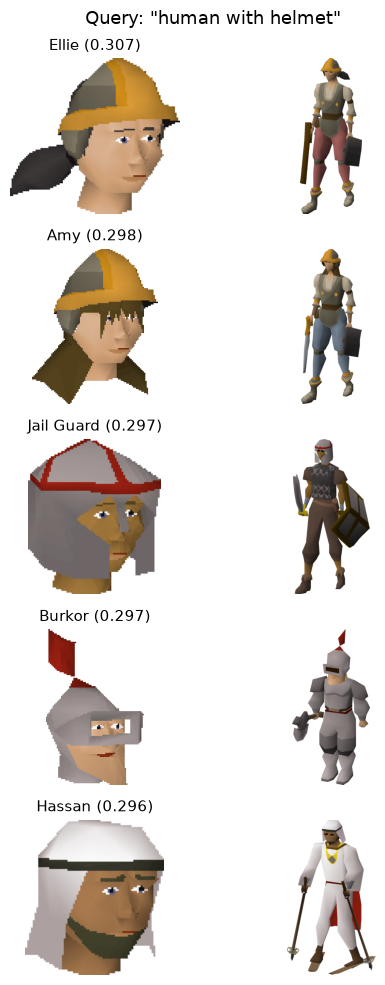

In [62]:
# usage
query = "human with helmet"
results = search(query)
plot_results(results, query)

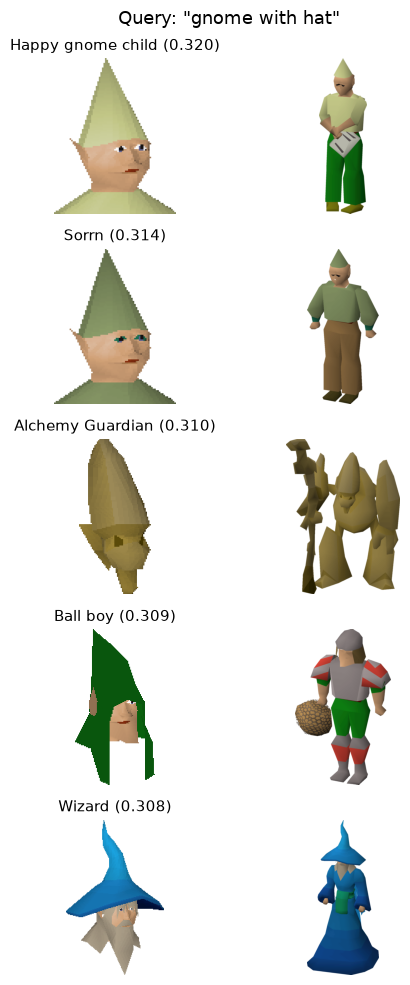

In [63]:
# usage
query = "gnome with hat"
results = search(query)
plot_results(results, query)

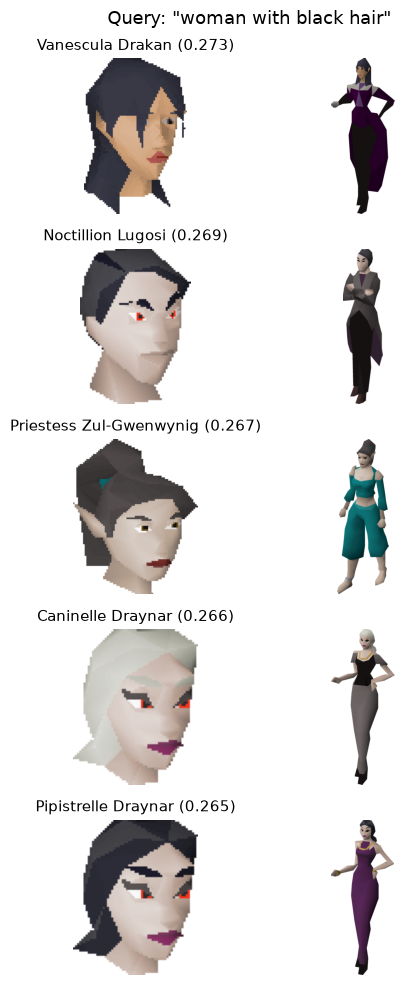

In [65]:
# usage
query = "woman with black hair"
results = search(query)
plot_results(results, query)

Image-to-image search — easy, already have everything needed. Instead of encoding a text query, encode the input image through CLIP and do the same cosine similarity against combined. One function change.

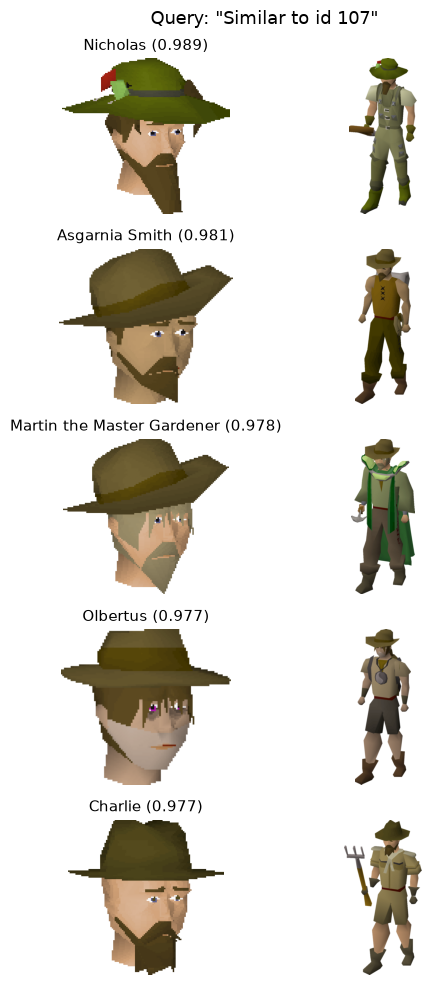

In [67]:
def search_by_image(npc_id, top_k=5):
    ch_img = Image.open(f"../data/chatheads/{npc_id}.png").convert("RGB")
    b_img = Image.open(f"../data/bodies/{npc_id}.png").convert("RGB")
    
    ch_inputs = clip_processor(text=["image"], images=ch_img, return_tensors="pt", padding=True).to(device)
    b_inputs = clip_processor(text=["image"], images=b_img, return_tensors="pt", padding=True).to(device)
    
    with torch.no_grad():
        ch_emb = clip_model(**ch_inputs).image_embeds.cpu().numpy()
        b_emb = clip_model(**b_inputs).image_embeds.cpu().numpy()
    
    query_emb = normalize((ch_emb + b_emb) / 2)
    scores = (combined @ query_emb.T).squeeze()
    
    # exclude the query NPC itself
    query_idx = np.where(npc_ids == npc_id)[0]
    scores[query_idx] = -1
    
    top_idx = np.argsort(-scores)[:top_k]
    return [
        {"id": int(npc_ids[i]), "name": df.loc[df["id"] == npc_ids[i], "Name"].values[0], "score": float(scores[i])}
        for i in top_idx
    ]

# usage
results = search_by_image(107)
plot_results(results, f"Similar to id {107}")

# t-SNE POC

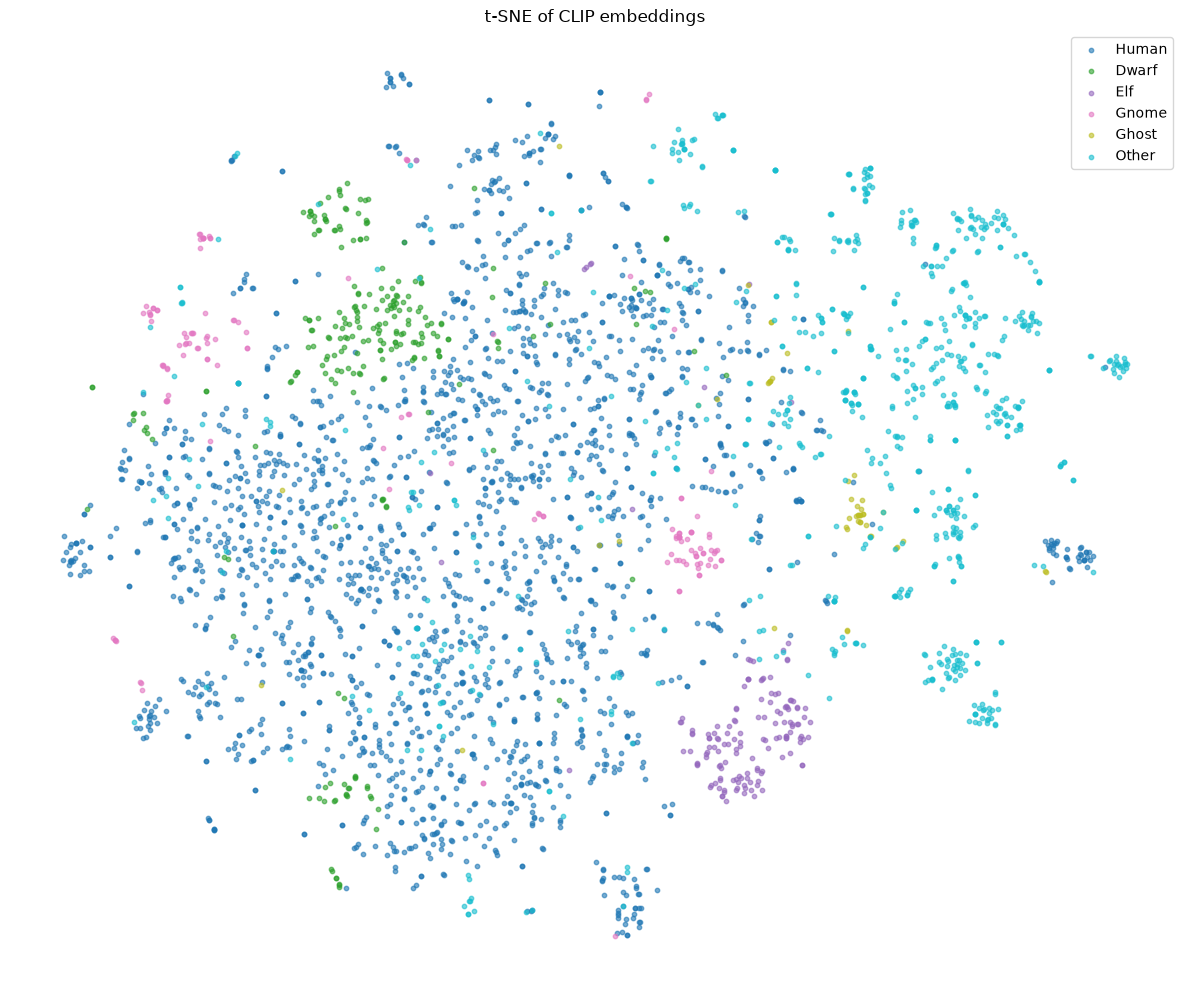

In [68]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedded = tsne.fit_transform(combined)

# color by class
id_to_label = df.set_index("id")["Class"]
labels = [id_to_label.get(i, "Other") for i in npc_ids]

TOP = df["Class"].value_counts().head(5).index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(TOP) + 1))
color_map = {cls: colors[i] for i, cls in enumerate(TOP)}
color_map["Other"] = colors[-1]

fig, ax = plt.subplots(figsize=(12, 10))
for cls in TOP + ["Other"]:
    mask = np.array([l == cls if l in TOP else cls == "Other" for l in labels])
    ax.scatter(embedded[mask, 0], embedded[mask, 1], label=cls, alpha=0.6, s=10, color=color_map[cls])

ax.legend()
ax.set_title("t-SNE of CLIP embeddings")
ax.axis("off")
plt.tight_layout()
plt.show()

# Prep data for a better, separate t-SNE

In [75]:
import base64
from io import BytesIO

def img_to_base64(path):
    img = Image.open(path).convert("RGBA")
    bg = Image.new("RGBA", img.size, (26, 26, 46, 255))  # #1a1a2e
    bg.paste(img, mask=img.split()[3])
    img = bg.convert("RGB").resize((20, 20), Image.NEAREST)
    buf = BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

sample_counts = {
    "Dorgeshuun": None,  # all
    "Monkey": None,
    "Cat": None,
    "Vampyre": None,
    "Ghost": 100,
    "Gnome": 100,
    "Elf": 100,
    "Dwarf": 100,
    "Human": 200,
}

# need Class column
df_clip = df[df["has_chathead"] & df["has_body"]].copy()

sampled = []
for cls, n in sample_counts.items():
    subset = df_clip[df_clip["Class"] == cls]
    sampled.append(subset if n is None else subset.sample(min(n, len(subset)), random_state=42))

sampled_df = pd.concat(sampled).reset_index(drop=True)
print(sampled_df["Class"].value_counts())

Class
Human         200
Gnome         100
Elf           100
Dwarf         100
Vampyre        61
Ghost          49
Monkey         42
Dorgeshuun     40
Cat            30
Name: count, dtype: int64


## figure out t-sne cords, write JSON with x/y coords,, name, class, id, and path to chathead

In [77]:
data = []
for i, (_, row) in enumerate(sampled_df.iterrows()):
    data.append({
        "id": int(row["id"]),
        "name": row["Name"],
        "cls": row["Class"],
        "x": float(embedded[i, 0]),
        "y": float(embedded[i, 1]),
        "img": f"../data/chatheads/{int(row['id'])}.png"
    })

with open("../tsne-viz/tsne_data.json", "w") as f:
    json.dump(data, f)